Attention shape: torch.Size([1, 9, 7, 7])
Max: 1.0, Min: 0.0, Mean: 0.142857164144516
Graph constructed with 15 edges.
Attention shape: torch.Size([1, 9, 6, 6])
Max: 1.0, Min: 0.0, Mean: 0.1666666567325592
Graph constructed with 12 edges.
Attention shape: torch.Size([1, 9, 8, 8])
Max: 1.0, Min: 0.0, Mean: 0.1250000149011612
Graph constructed with 16 edges.
Epoch 1 | Loss: 9.648520, Degree: 3.52, Clustering: 0.63, Density: 0.60
Attention shape: torch.Size([1, 9, 7, 7])
Max: 1.0, Min: 0.0, Mean: 0.1428571492433548
Graph constructed with 15 edges.
Attention shape: torch.Size([1, 9, 6, 6])
Max: 1.0, Min: 0.0, Mean: 0.1666666567325592
Graph constructed with 12 edges.
Attention shape: torch.Size([1, 9, 8, 8])
Max: 1.0, Min: 0.0, Mean: 0.125
Graph constructed with 16 edges.
Epoch 2 | Loss: 5.105444, Degree: 3.43, Clustering: 0.70, Density: 0.58
Attention shape: torch.Size([1, 9, 7, 7])
Max: 1.0, Min: 0.0, Mean: 0.1428571492433548
Graph constructed with 15 edges.
Attention shape: torch.Size([1

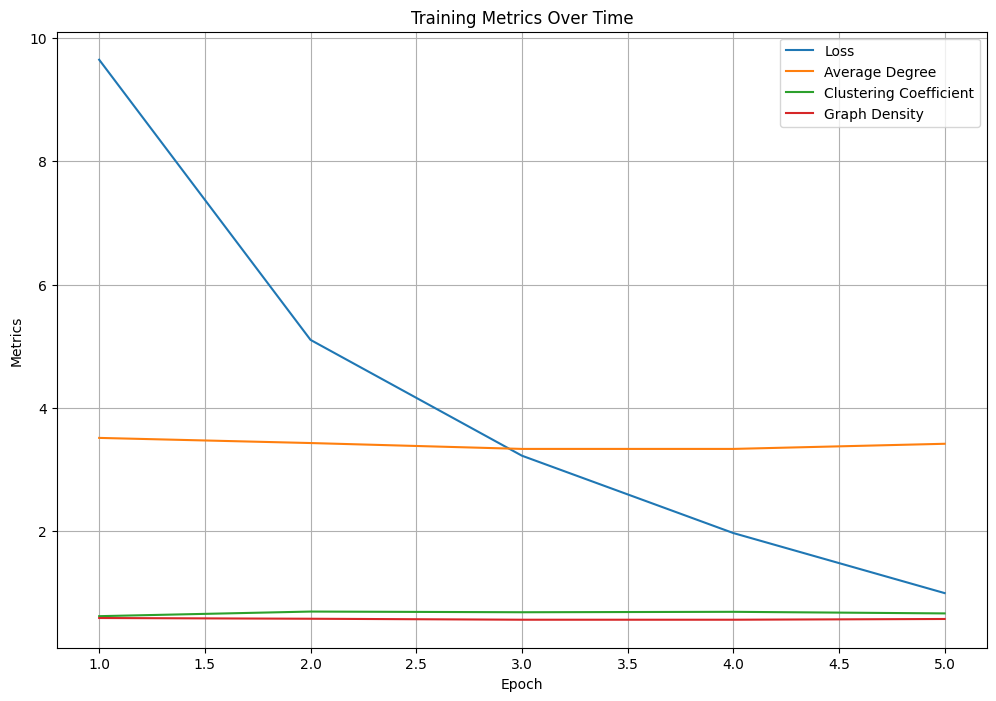

In [ ]:
import torch
import torch.nn as nn
import networkx as nx
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from typing import Tuple, Optional
import matplotlib.pyplot as plt

class RhizomeOptimizer:
    def __init__(
        self,
        model: nn.Module,
        lr: float = 5e-5,
        alpha: float = 0.1,
        beta: float = 0.1,
        device: str = "cpu",
        top_k: int = 3
    ):
        self.model = model
        self.lr = lr
        self.alpha = alpha
        self.beta = beta
        self.device = device
        self.top_k = top_k
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    def build_graph_from_attention(self, attention_scores: torch.Tensor) -> nx.Graph:
        """Construct a graph from the top-k attention scores."""
        attention_scores = attention_scores.detach().cpu()
        attention_scores = attention_scores.mean(dim=1)  # Average across heads

        num_tokens = attention_scores.size(-1)
        G = nx.Graph()
        G.add_nodes_from(range(num_tokens))

        edge_count = 0
        for i in range(num_tokens):
            # Get top-k attention scores for each token
            topk_indices = torch.topk(attention_scores[0, i], self.top_k).indices
            for j in topk_indices:
                if i != j:  # Avoid self-loops unless explicitly desired
                    G.add_edge(i, j.item(), weight=float(attention_scores[0, i, j]))
                    edge_count += 1

        print(f"Graph constructed with {edge_count} edges.")
        return G

    def compute_graph_metrics(self, graph: nx.Graph) -> Tuple[float, float, float]:
        """Calculate graph metrics."""
        if len(graph) == 0:
            return 0.0, 0.0, 0.0
        degree = sum(dict(graph.degree()).values()) / len(graph)
        clustering = nx.average_clustering(graph) if len(graph) > 1 else 0.0
        density = nx.density(graph)
        return degree, clustering, density

    def compute_loss_and_metrics(
        self,
        predictions: torch.Tensor,
        targets: torch.Tensor,
        attention_scores: torch.Tensor
    ) -> Tuple[torch.Tensor, float, float, float]:
        """Compute combined loss and graph metrics."""
        criterion = nn.CrossEntropyLoss()
        traditional_loss = criterion(predictions.view(-1, predictions.size(-1)), targets.view(-1))

        graph = self.build_graph_from_attention(attention_scores)
        degree, clustering, density = self.compute_graph_metrics(graph)

        degree_tensor = torch.tensor(degree, device=self.device)
        clustering_tensor = torch.tensor(clustering, device=self.device)

        rhizome_loss_value = traditional_loss - self.alpha * degree_tensor + self.beta * clustering_tensor
        return rhizome_loss_value, degree, clustering, density

    def optimize_step(
        self,
        predictions: torch.Tensor,
        targets: torch.Tensor,
        attention_scores: torch.Tensor
    ) -> Tuple[float, float, float, float]:
        """Perform an optimization step."""
        loss, degree, clustering, density = self.compute_loss_and_metrics(predictions, targets, attention_scores)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item(), degree, clustering, density

# Load the model and tokenizer with attention outputs enabled
checkpoint = "HuggingFaceTB/SmolLM-135M"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForCausalLM.from_pretrained(checkpoint, output_attentions=True).to(device)

rhizome_optimizer = RhizomeOptimizer(
    model=model,
    lr=5e-5,
    alpha=0.1,
    beta=0.1,
    device=device,
    top_k=3
)

# Train the model and visualize results
metrics_log = train_smol_lm(model, tokenizer, rhizome_optimizer, device)
plot_metrics(metrics_log)

Loading model and tokenizer from HuggingFaceTB/SmolLM-135M...
Setting up padding token...
Initializing RhizomeOptimizer...
Starting training...
Epoch 1/3
Graph constructed with 17 edges.
Step 0: Loss: 3.8186, Degree: 3.5000, Clustering: 0.6458, Density: 0.5000
Graph constructed with 16 edges.
Graph constructed with 12 edges.
Graph constructed with 17 edges.
Graph constructed with 17 edges.
Graph constructed with 16 edges.
Step 5: Loss: 1.7013, Degree: 3.5000, Clustering: 0.6458, Density: 0.5000
Graph constructed with 17 edges.
Graph constructed with 19 edges.
Graph constructed with 16 edges.
Graph constructed with 14 edges.
Graph constructed with 19 edges.
Step 10: Loss: 3.0275, Degree: 3.7778, Clustering: 0.6839, Density: 0.4722
Graph constructed with 14 edges.
Graph constructed with 17 edges.
Graph constructed with 12 edges.
Graph constructed with 17 edges.
Graph constructed with 17 edges.
Step 15: Loss: 0.5893, Degree: 3.7500, Clustering: 0.6726, Density: 0.5357
Graph constructed wi

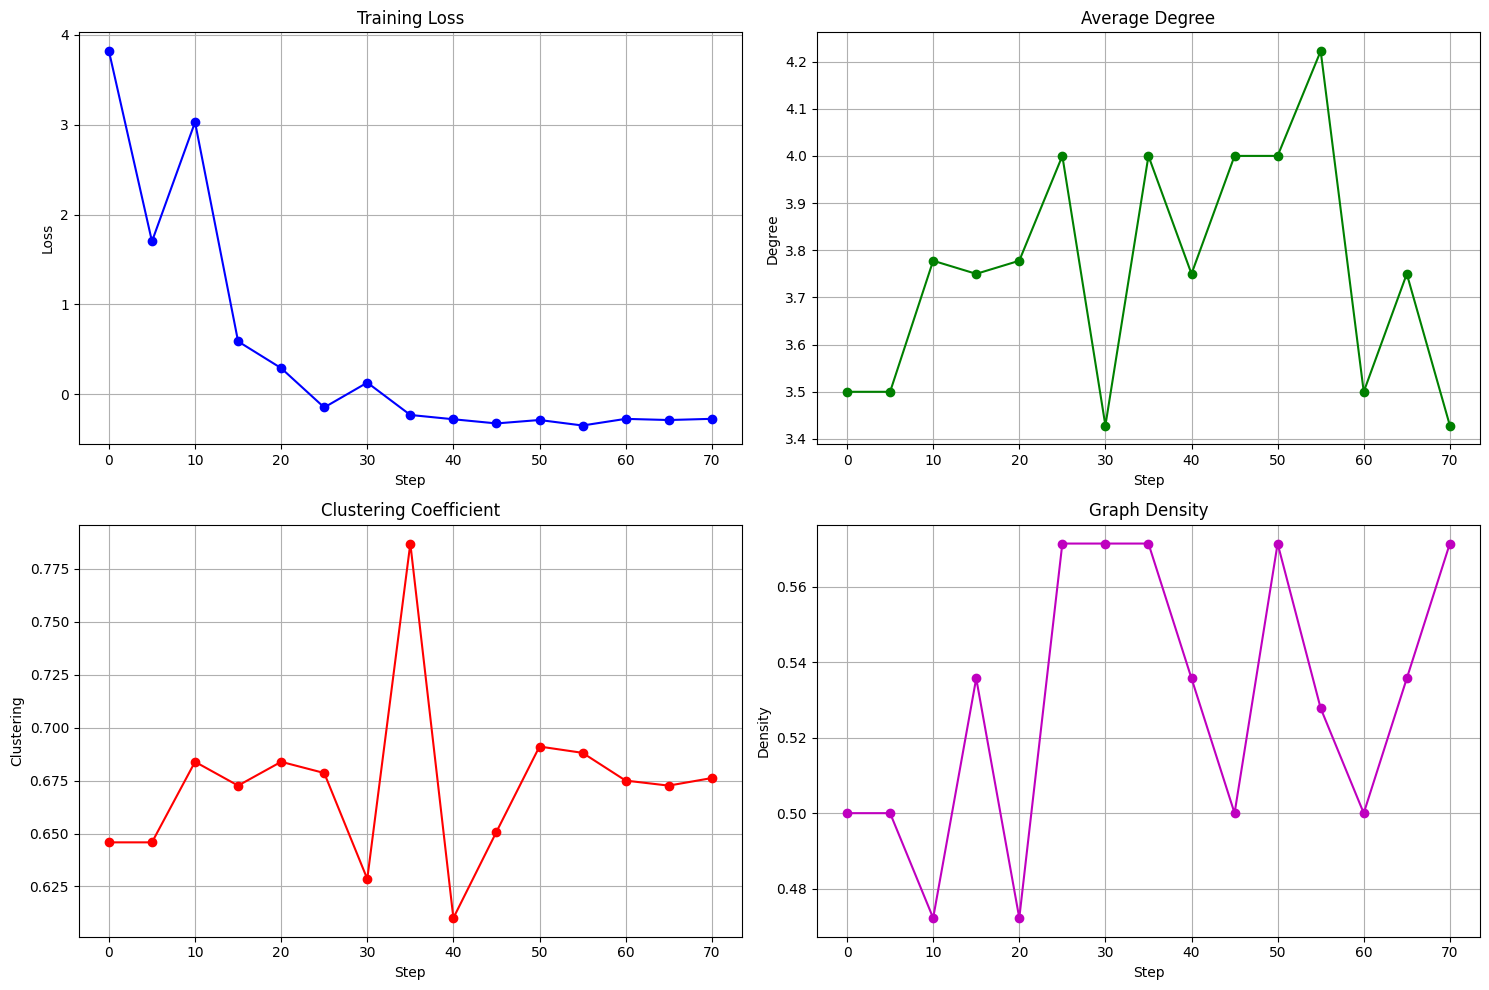

In [ ]:
# [Previous imports and RhizomeOptimizer class remain the same]

def train_smol_lm(
    model: nn.Module,
    tokenizer: AutoTokenizer,
    rhizome_optimizer: RhizomeOptimizer,
    device: str,
    num_epochs: int = 3,
    batch_size: int = 2,
    max_length: int = 64,
    eval_steps: int = 5  # Reduced to collect metrics more frequently
) -> dict:
    """
    Train the language model using the RhizomeOptimizer.
    """
    # Expanded training data for better visualization
    train_texts = [
        "The quick brown fox jumps over the lazy dog",
        "Machine learning is a fascinating field of study",
        "Neural networks can learn complex patterns",
        "Deep learning has revolutionized artificial intelligence",
        "Transformers are powerful language models",
        "Graph neural networks combine structure with learning",
        "Attention mechanisms help models focus on important parts",
        "Language models can generate human-like text",
        "Optimization algorithms help models learn efficiently",
        "Data preprocessing is crucial for good results"
    ] * 5  # Repeat the data to get more training iterations

    metrics_log = {
        'loss': [],
        'degree': [],
        'clustering': [],
        'density': [],
        'step': []
    }

    step = 0
    model.train()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Shuffle the training data at the start of each epoch
        np.random.shuffle(train_texts)

        for i in range(0, len(train_texts), batch_size):
            batch_texts = train_texts[i:i + batch_size]

            # Tokenize and prepare input
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            # Prepare targets (shifted input_ids for language modeling)
            labels = inputs.input_ids.clone()
            labels = torch.roll(labels, shifts=-1, dims=1)
            labels[:, -1] = -100  # Ignore last token prediction

            # Forward pass
            outputs = model(**inputs, labels=labels, output_attentions=True)
            logits = outputs.logits
            attention_scores = outputs.attentions[-1]  # Use last layer attention

            # Optimization step
            loss, degree, clustering, density = rhizome_optimizer.optimize_step(
                logits,
                labels,
                attention_scores
            )

            # Log metrics every eval_steps
            if step % eval_steps == 0:
                metrics_log['loss'].append(float(loss))  # Ensure we're storing float values
                metrics_log['degree'].append(float(degree))
                metrics_log['clustering'].append(float(clustering))
                metrics_log['density'].append(float(density))
                metrics_log['step'].append(step)

                print(f"Step {step}: Loss: {loss:.4f}, Degree: {degree:.4f}, "
                      f"Clustering: {clustering:.4f}, Density: {density:.4f}")

            step += 1

    return metrics_log

def plot_metrics(metrics_log: dict):
    """
    Plot training metrics over time with improved visualization.
    """
    if not metrics_log['step']:
        print("No metrics to plot!")
        return

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Plot loss with appropriate scaling
    ax1.plot(metrics_log['step'], metrics_log['loss'], 'b-', marker='o')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    # Plot average degree
    ax2.plot(metrics_log['step'], metrics_log['degree'], 'g-', marker='o')
    ax2.set_title('Average Degree')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Degree')
    ax2.grid(True)

    # Plot clustering coefficient
    ax3.plot(metrics_log['step'], metrics_log['clustering'], 'r-', marker='o')
    ax3.set_title('Clustering Coefficient')
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Clustering')
    ax3.grid(True)

    # Plot graph density
    ax4.plot(metrics_log['step'], metrics_log['density'], 'm-', marker='o')
    ax4.set_title('Graph Density')
    ax4.set_xlabel('Step')
    ax4.set_ylabel('Density')
    ax4.grid(True)

    plt.tight_layout()

    # Print metric ranges to verify data
    print("\nMetric ranges:")
    for metric in ['loss', 'degree', 'clustering', 'density']:
        values = metrics_log[metric]
        if values:
            print(f"{metric}: min={min(values):.4f}, max={max(values):.4f}")

    plt.show()

# Main execution block remains the same as in the previous version, but you might want to adjust hyperparameters:
if __name__ == "__main__":
    checkpoint = "HuggingFaceTB/SmolLM-135M"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Loading model and tokenizer from {checkpoint}...")
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForCausalLM.from_pretrained(checkpoint, output_attentions=True).to(device)

    # Set up padding token
    print("Setting up padding token...")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.pad_token_id

    print("Initializing RhizomeOptimizer...")
    rhizome_optimizer = RhizomeOptimizer(
        model=model,
        lr=5e-5,
        alpha=0.1,
        beta=0.1,
        device=device,
        top_k=3
    )

    print("Starting training...")
    metrics_log = train_smol_lm(
        model=model,
        tokenizer=tokenizer,
        rhizome_optimizer=rhizome_optimizer,
        device=device,
        num_epochs=3,
        batch_size=2,
        eval_steps=5
    )

    print("Training complete. Plotting metrics...")
    plot_metrics(metrics_log)